In [15]:
%load_ext autoreload
%autoreload 2
import os,sys
import torch
import numpy as np
import pandas as pd
import scanpy as sc
import PINN
from PINN import reader, models
from torchdiffeq import odeint
from TorchDiffEqPack.odesolver import odesolve
from torchdyn.core import NeuralODE
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib import cm

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
os.chdir("/ssd/users/Wergillius/Project/PINN_dynamics")

In [94]:
adata = sc.read_h5ad(f"data/tom_pos.h5ad")

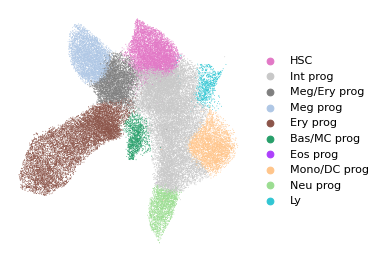

In [ ]:
dpi = 80 # change here to plot high res fig and save 

fig = plt.figure(figsize=(6,4), dpi=dpi, frameon=False)
gs = GridSpec(1, 3)
ax1 = fig.add_subplot(gs[0:2])
sc.pl.umap(adata, color='fine_anno', frameon=False,  ax=ax1, title='')

if dpi==600:
    fig.savefig("figures/tompos_celltype_refined.pdf", format="pdf",transparent=True)

In [43]:
adata.write_h5ad(f"data/tom_pos.h5ad")

In [108]:
comb_ad = sc.read_h5ad("data/combined_filt.h5ad")

In [109]:
comb_HSC = comb_ad[comb_ad.obs.anno_man == 'HSC'].copy()

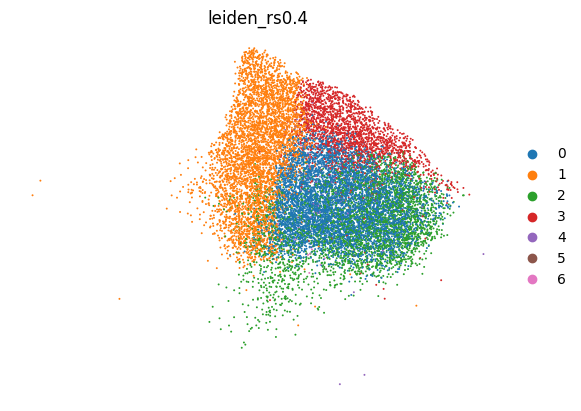

In [111]:
sc.tl.leiden(comb_HSC, resolution=0.4, key_added='leiden_rs0.4')
sc.pl.umap(comb_HSC, color='leiden_rs0.4', frameon=False)

In [ ]:
comb_HSC

# vwf expressed cells

In [45]:
np.where(adata.var_names == 'Vwf')

(array([1813]),)

In [ ]:
# adata.obs['Vwf'] = adata.X[:,1813].A.flatten()
adata.obs['Vwf+'] = adata.X[:,1813].A.flatten() > 0

In [96]:
adata.obs['timepoint_tx_days'] = adata.obs['timepoint_tx_days'].astype(str)

/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/site-packages/anndata/_core/anndata.py:1230: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


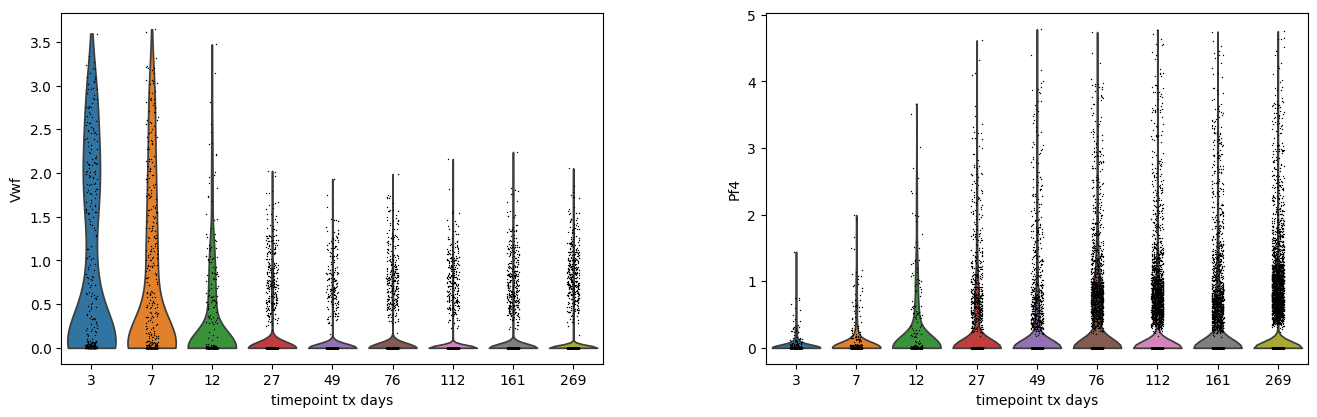

In [ ]:
sc.pl.violin(adata[adata.obs.anno_man.isin(['HSC', 'Int prog', 'Meg/Ery prog', 'Meg prog'])],
              ["Vwf"], groupby="timepoint_tx_days")

In [80]:
vwf_hsc = adata.obs.groupby(['timepoint_tx_days','fine_anno'])['Vwf+'].value_counts(normalize=True).reset_index()

In [81]:
cts = ['HSC', 'Int prog', 'Meg/Ery prog']
vwf_hsc = vwf_hsc.query("`fine_anno` in @cts")

In [82]:
vwf_hsc['fine_anno'] = vwf_hsc['fine_anno'].astype('object')

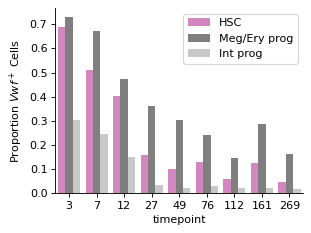

In [ ]:
dpi = 80

fig, ax = plt.subplots(figsize=(4,3), dpi=dpi, frameon=False)
import seaborn as sns
sns.barplot(data=vwf_hsc.query("`Vwf+` == True"), 
            x='timepoint_tx_days', y='proportion', hue='fine_anno',
            order=[str(t) for t in adata.uns['pop']['t']],
            hue_order = ['HSC', 'Meg/Ery prog', 'Int prog'],
            palette=new_palette, saturation=0.7,
            ax=ax
            )
ax.legend(title=False)
ax.set_ylabel(f"Proportion $Vwf^+$ Cells")
ax.set_xlabel("timepoint")
sns.despine(ax=ax)

if dpi==600:
    fig.savefig('figures/tompos_vwf+_propor.pdf', format='pdf', transparent=True)

# gene list

In [118]:
gene_list_df = pd.read_csv('data/mouse_geneset/Rodriguez-Fraticelli_HSC_gene_signatures.csv', skiprows=1).iloc[:,:17]
gene_list_df = gene_list_df.fillna('')


gene_list_df.head()


,Low-output_Rodriguez_et_al,High-output_Rodriguez_et_al,Multilineage_Rodriguez_et_al,Mk-bias_Rodriguez_et_al,Serial-engraftment_Rodriguez_et_al,Stemscore_Giladi_et_al,RACFP_DIM_Lauridsen_et_al,SuMO_Wilson_et_al,MolO_Wilson_et_al,HSC_vs_MPP4_Cabezas-Wallscheid_et_al,dHSC_vs_aHSC_Cabezas-Wallscheid_et_al,HSC_Pietras_et_al,HSC1 cluster,HSC2 cluster,HSC3 cluster,HSC4 cluster,dHSC_aHSC_single-cell_Cabezas-Wallscheid_et_al
0,Mpl,Plac8,Plac8,Ifitm3,Ifitm1,1110017F19Rik,Ltb,Ly6a,Procr,Prss41,Bst1,Fzd3,Hlf,Fos,Ppia,Jun,ENSMUSG00000064339
1,Ifitm3,H2afy,H2afy,Rbms3,Tsc22d1,2410006H16Rik;Snord65,Lst1,Ifitm1,Pdzk1ip1,Sh3gl3,ENSMUSG00000080851,Lhcgr,mt-Co1,Zfp36,Ptma,Egr1,ENSMUSG00000098178
2,Ifitm1,Cdk6,Mpo,Ifitm1,Mycn,2900062L11Rik;6530401D17Rik,Ypel3,Inhba,Ltb,Ncam2,Ace,Kif21a,Ifitm3,Junb,Tuba1b,Ier2,CYTB
3,Tgm2,Cd34,Elane,Adgrg1,Vwf,4931406C07Rik,Ly6a,Mllt3,Mllt3,Sh3rf3,Blk,Pabpc4l,Mpl,Jun,Stmn1,Plac8,Serpinb1a
4,H2-K1,Nkg7,Ybx1,Tsc22d1,Glul,AK046388,Ctsf,Wfdc2,Ifitm1,Ak7,Gpr35,Abcg3,Iigp1,Jund,Hmgb2,Ptma,Actb


In [113]:
raw_ad = adata.raw.to_adata()

In [114]:
raw_ad.var_names

Index(['Gm37381', 'Rp1', 'Sox17', 'Gm37323', 'Mrpl15', 'Lypla1', 'Gm37988',
       'Tcea1', 'Rgs20', 'Gm16041',
       ...
       'Csprs', 'AC132444.6', 'AC125149.3', 'AC125149.1', 'AC125149.2',
       'AC168977.2', 'AC168977.1', 'AC149090.1', 'CAAA01118383.1',
       'CAAA01147332.1'],
      dtype='object', length=22035)

In [115]:
score_names = []
for sig in ['Low-output_Rodriguez_et_al', 'High-output_Rodriguez_et_al',
       'Multilineage_Rodriguez_et_al', 'Mk-bias_Rodriguez_et_al']:
    score_name = sig.replace("_Rodriguez_et_al", " score").replace("-", " ")
    gene_sig = [g for g in gene_list_df[sig].values if g != '']
    overlap = np.intersect1d(gene_sig, raw_ad.var_names)

    print(sig, len(gene_sig),len(overlap))
    sc.tl.score_genes(adata, overlap, score_name=score_name)

    score_names.append(score_name)


Low-output_Rodriguez_et_al 1513 1369


High-output_Rodriguez_et_al 1455 1296
Multilineage_Rodriguez_et_al 1037 966
Mk-bias_Rodriguez_et_al 901 857


In [ ]:
'Low-output_Rodriguez_et_al' in adata.obs_keys()

True

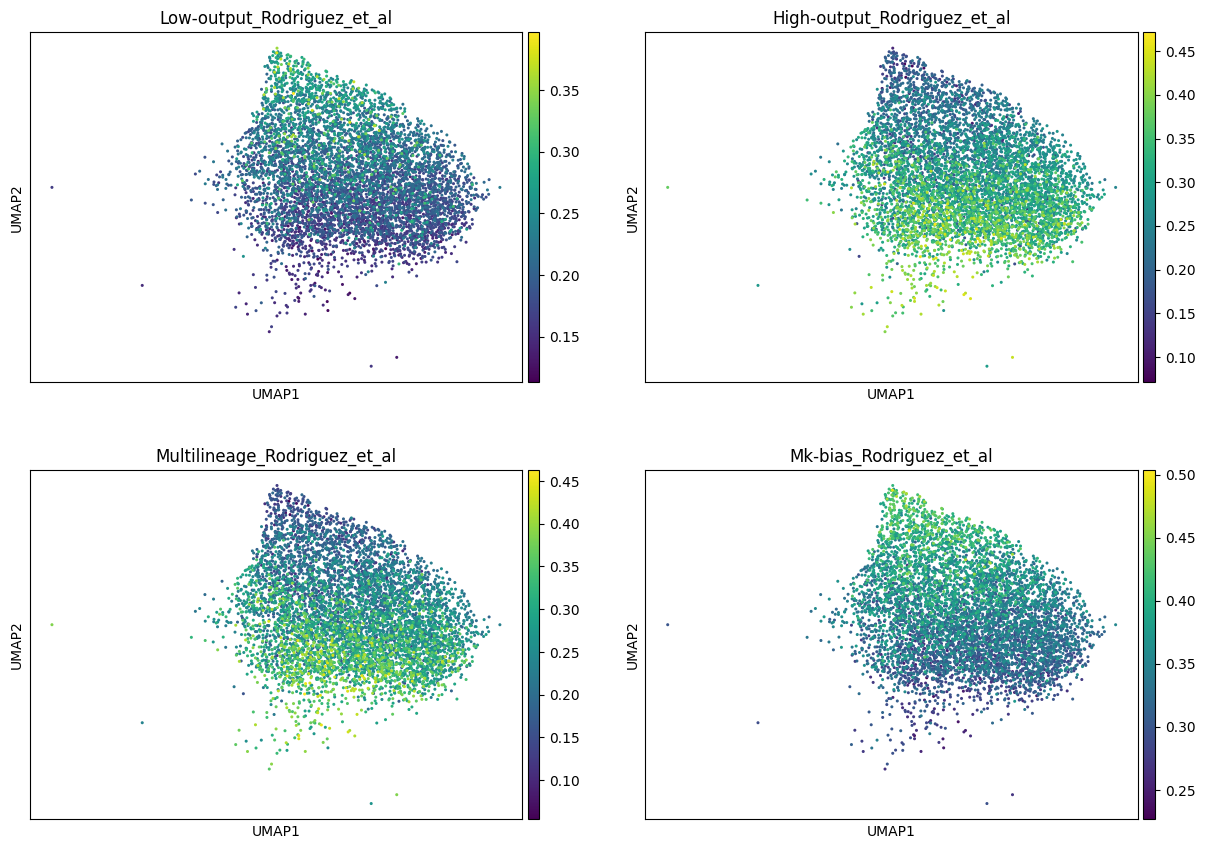

In [ ]:
sc.pl.umap(adata[adata.obs.anno_man == 'HSC'], color=list(gene_list_df.columns[:4]), ncols=2)

'#E278C6'

In [ ]:
colormap = sns.dark_palette(new_palette['HSC'], reverse=True, n_colors=12)
colormap

[(0.8862745098039215, 0.47058823529411764, 0.7764705882352941),
 (0.8213208233331304, 0.4408295606271192, 0.720676653797352),
 (0.7563671368623394, 0.41107088596012076, 0.6648827193594099),
 (0.6914134503915483, 0.38131221129312226, 0.6090887849214678),
 (0.6236356905959402, 0.3502596812058195, 0.5508690272470934),
 (0.5586820041251491, 0.3205010065388211, 0.4950750928091513),
 (0.49372831765435804, 0.29074233187182263, 0.43928115837120923),
 (0.42877463118356696, 0.2609836572048242, 0.38348722393326706),
 (0.3609968713879589, 0.22993112711752145, 0.3252674662588927),
 (0.29604318491716775, 0.200172452450523, 0.2694735318209506),
 (0.23108949844637672, 0.1704137777835245, 0.21367959738300846),
 (0.16613581197558552, 0.14065510311652607, 0.1578856629450664)]

/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/site-packages/anndata/_core/anndata.py:1230: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/site-packages/scanpy/plotting/_anndata.py:900: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/site-packages/anndata/_core/anndata.py:1230: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/site-packages/scanpy/plotting/_anndata.py:900: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable

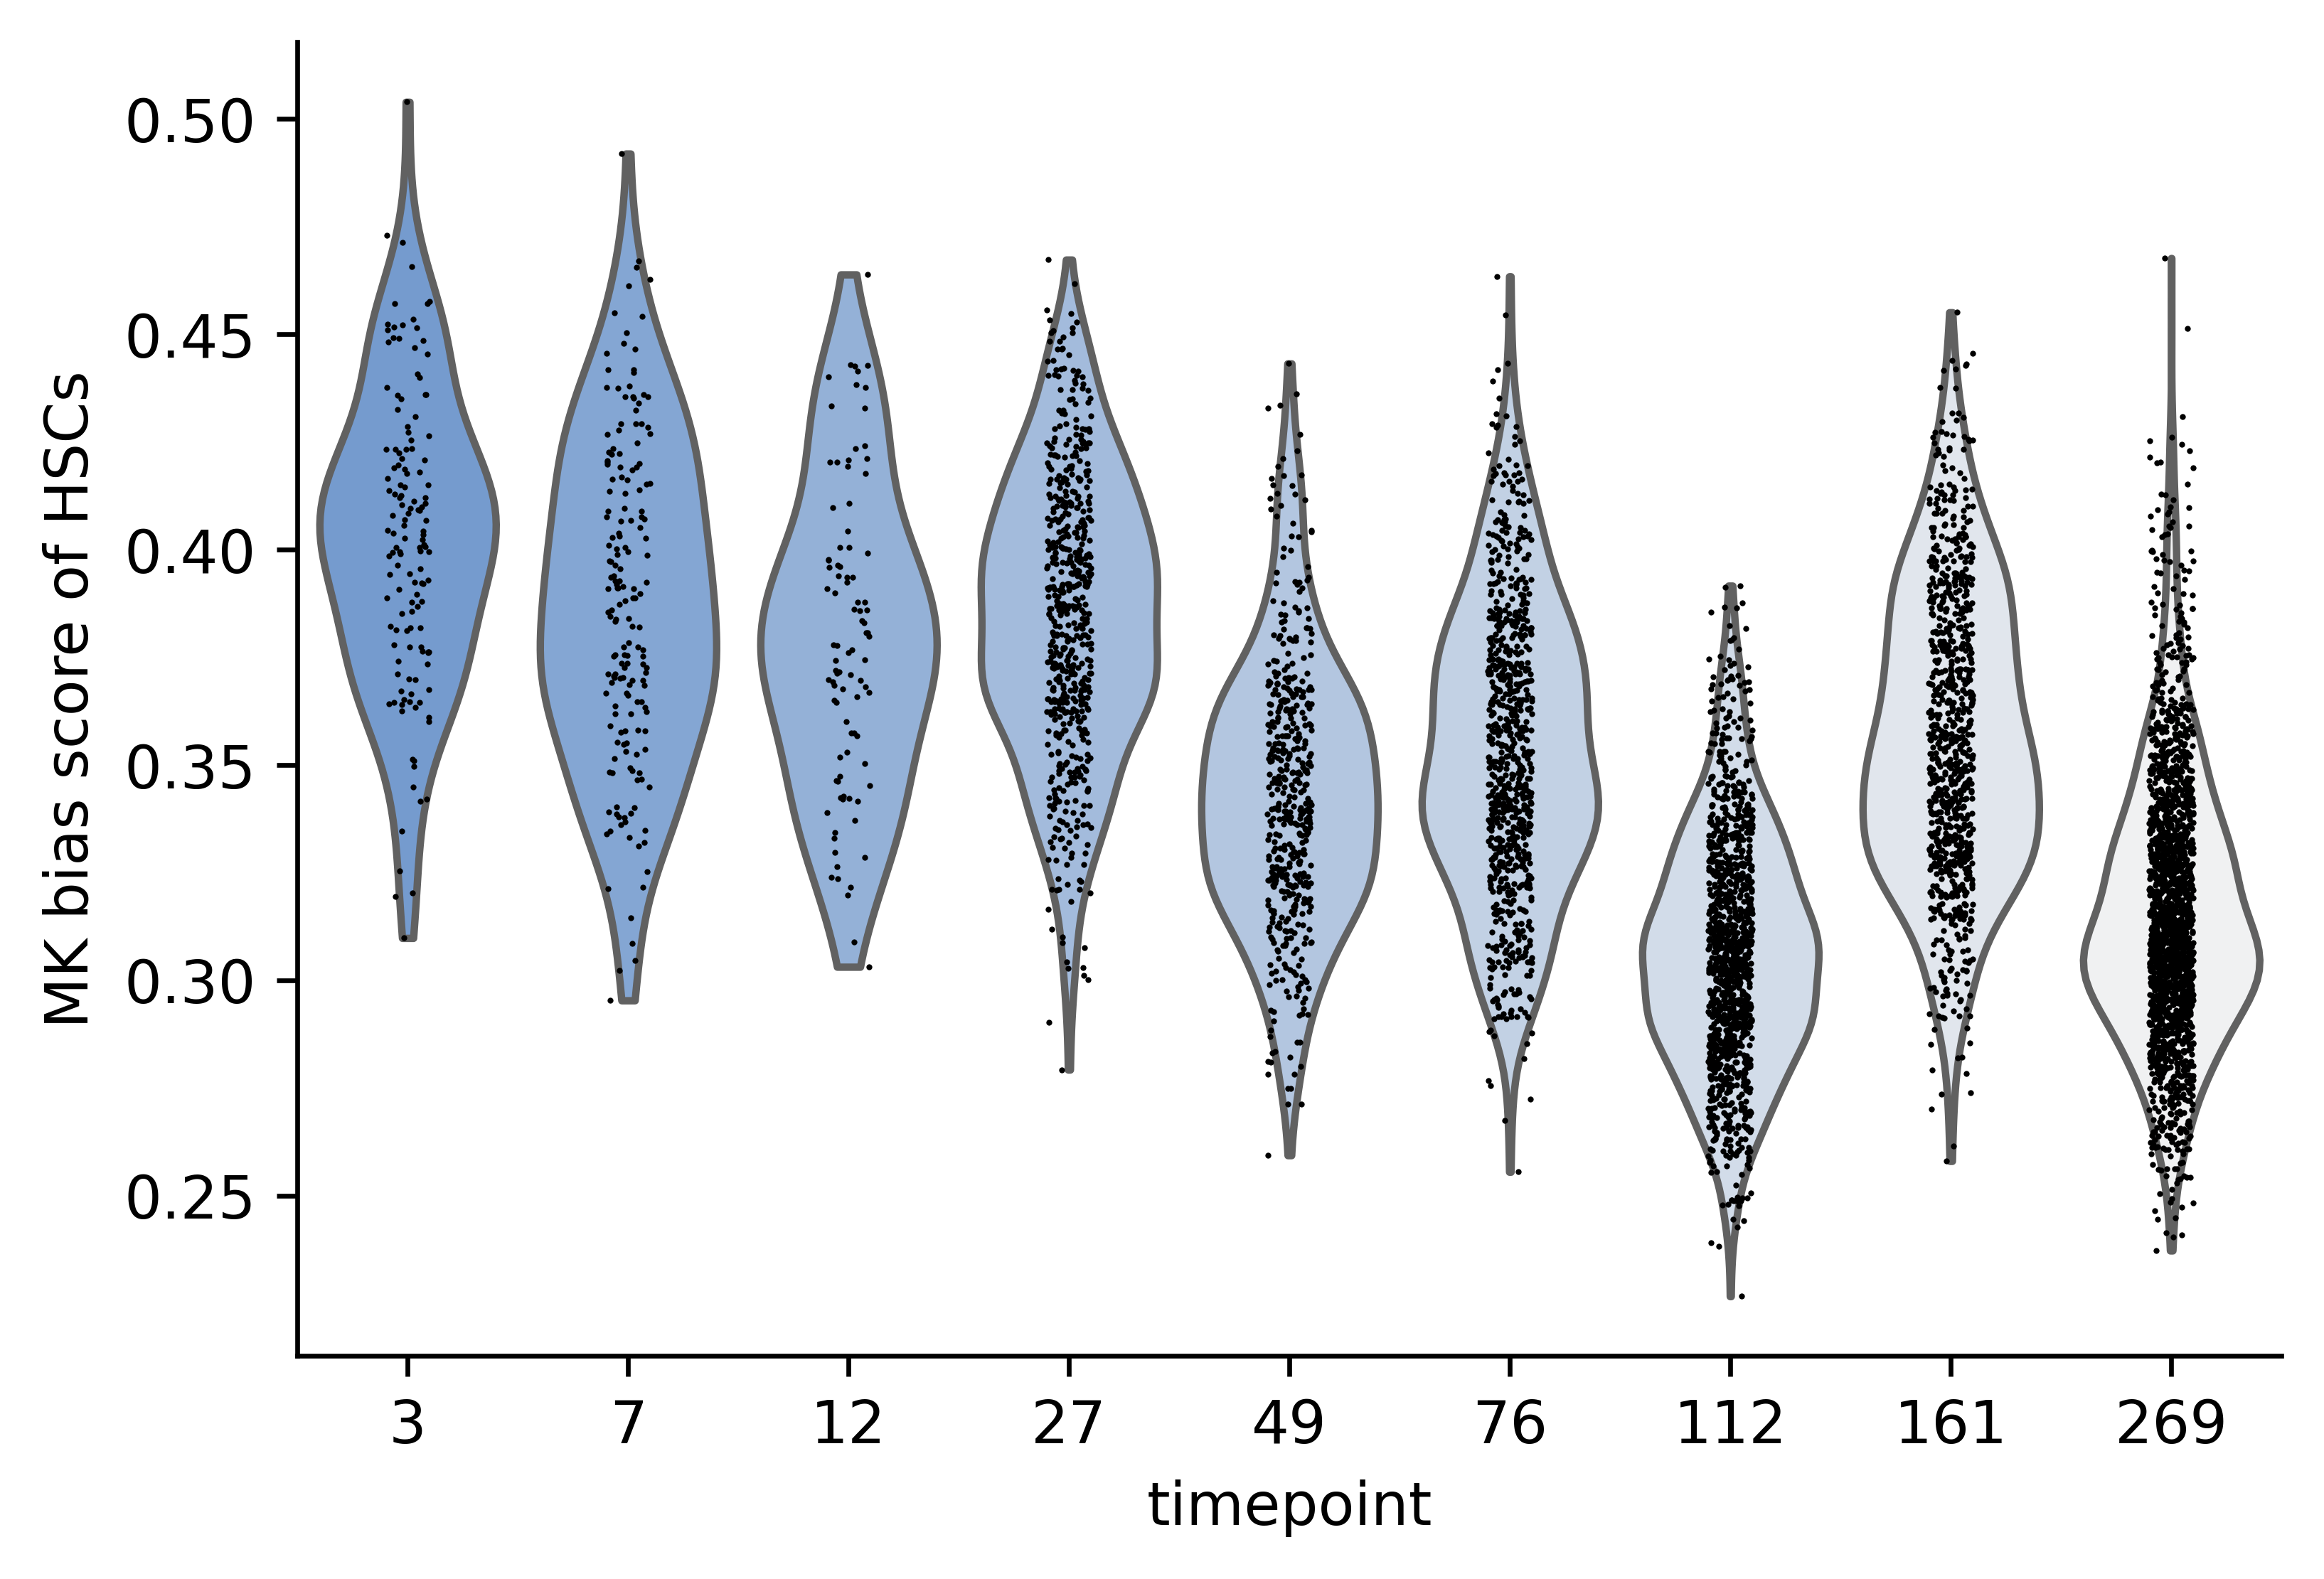

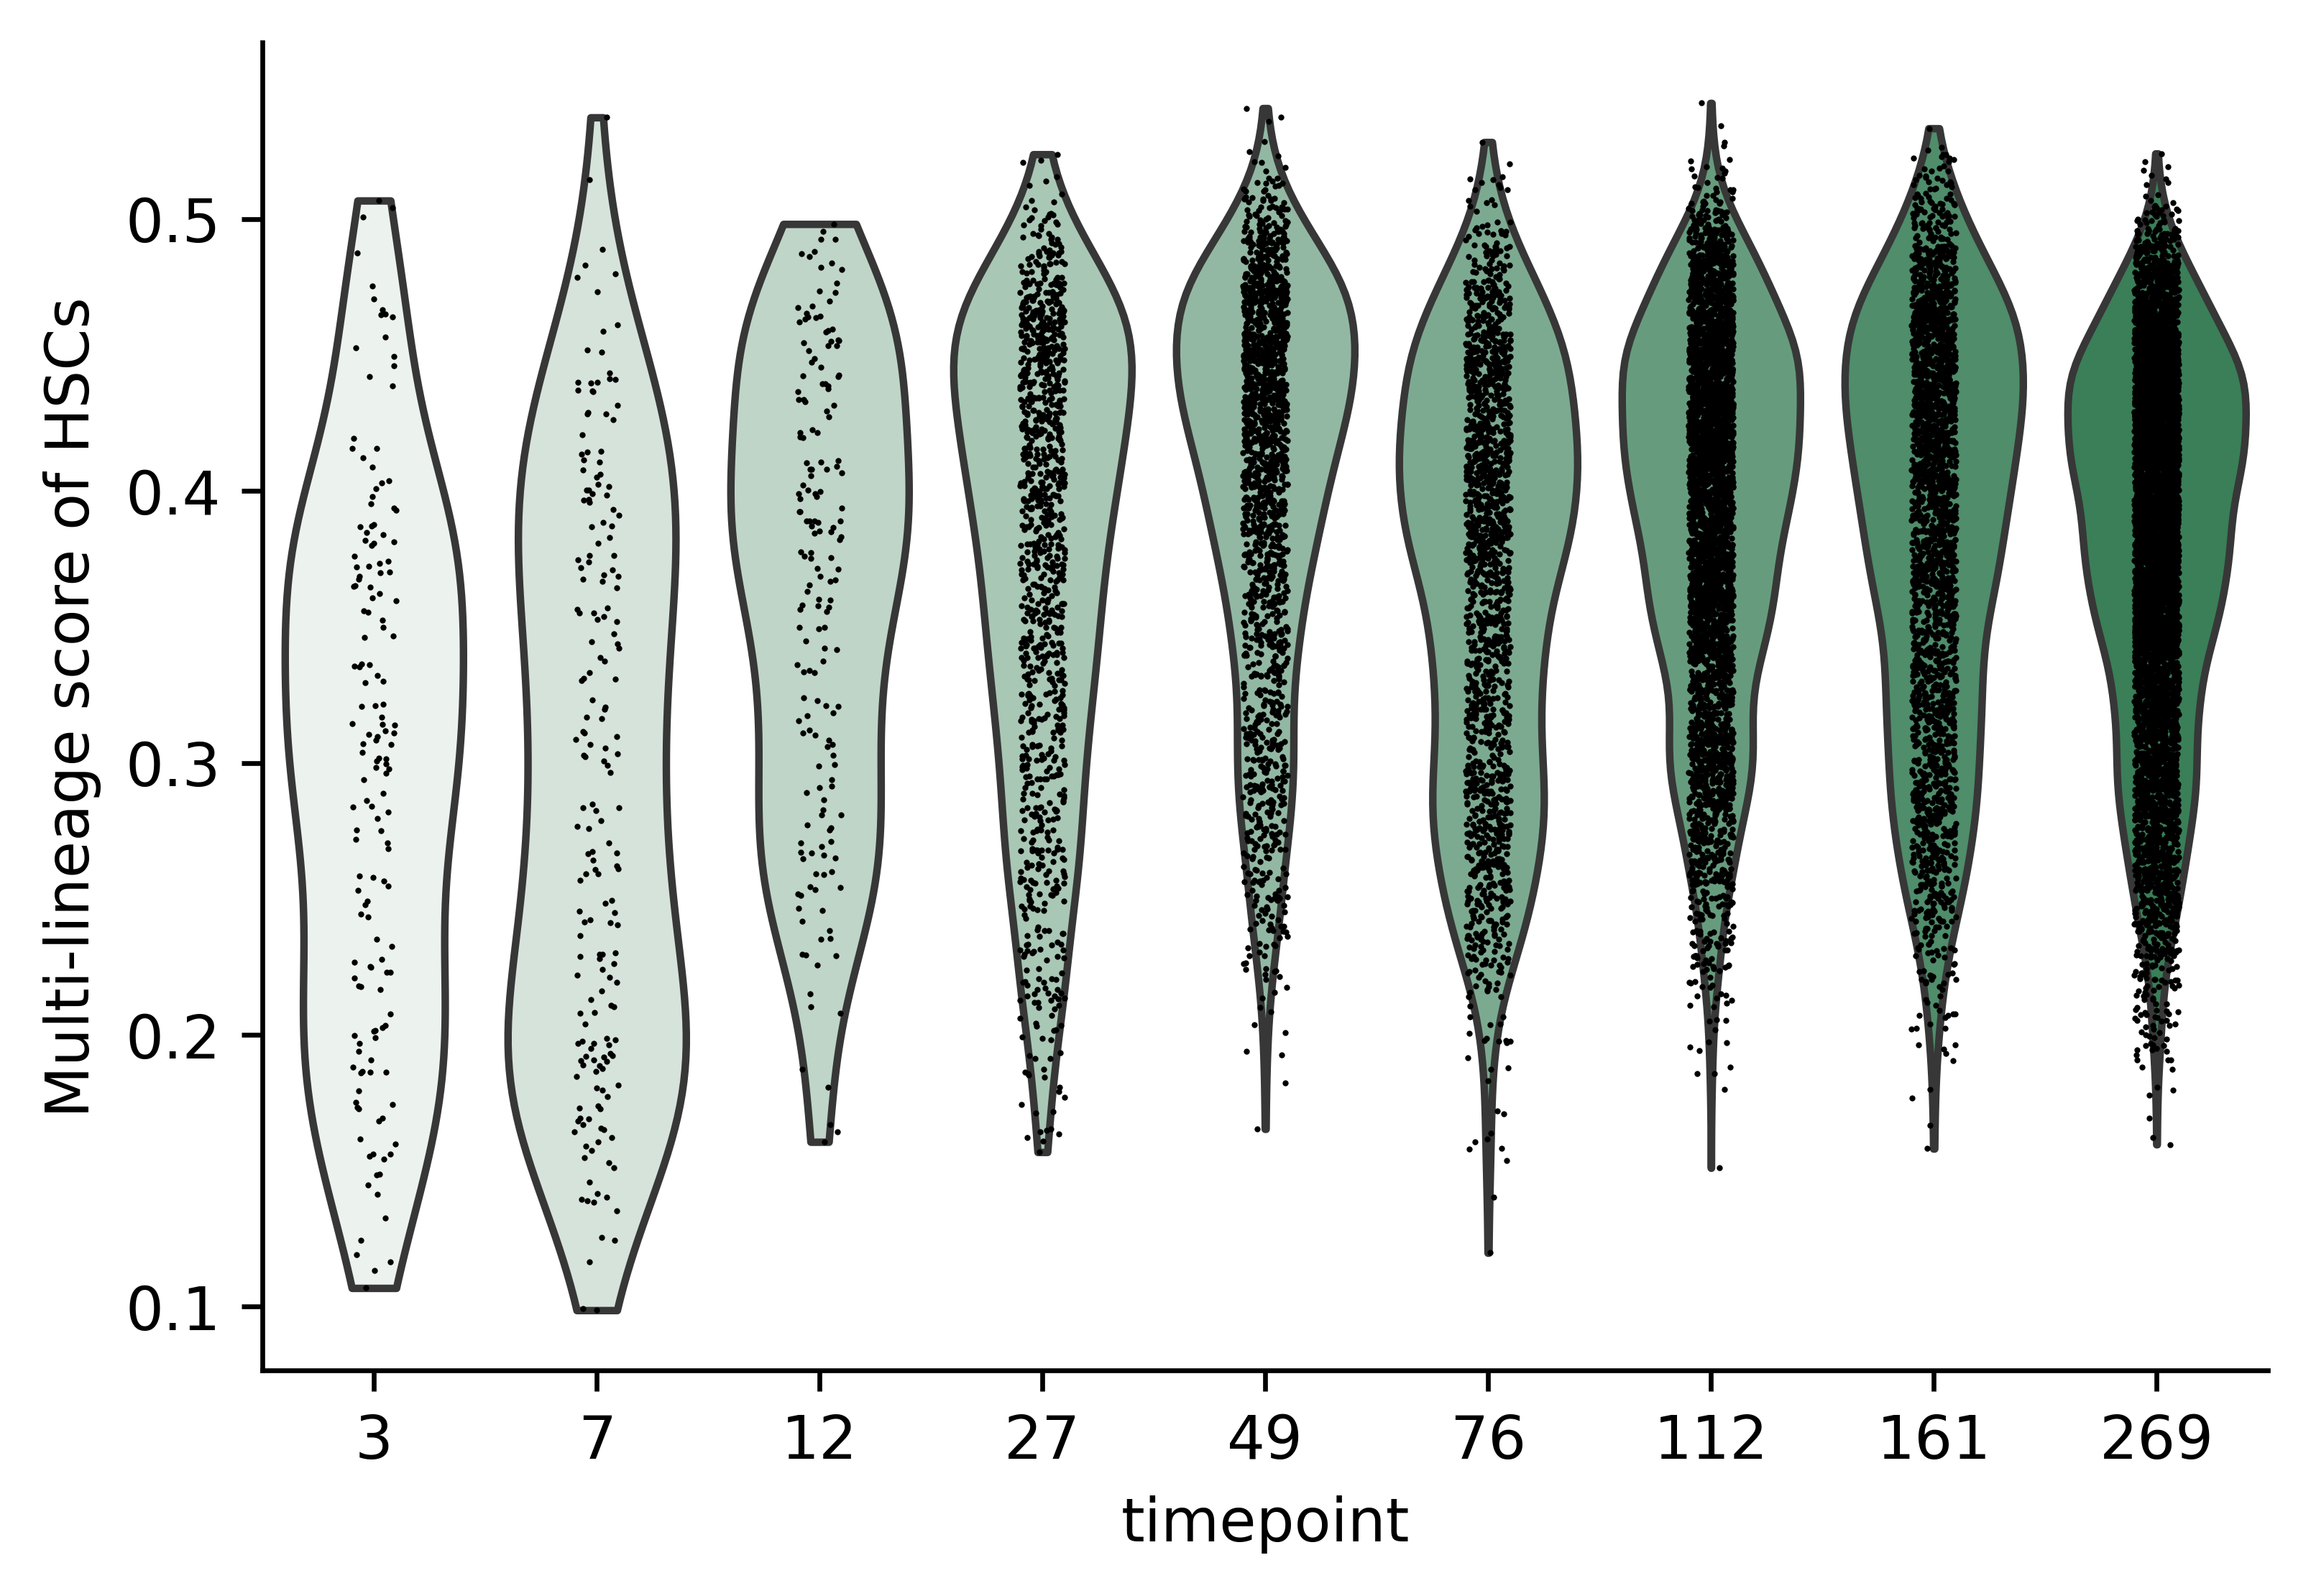

In [ ]:
adata.obs['timepoint'] = adata.obs['timepoint_tx_days'].astype(str)

dpi = 600

fig = plt.figure(figsize=(6,4), dpi=dpi, frameon=False)
gs = GridSpec(3,3)
ax1 = fig.add_subplot(gs[:, :])


colormap = sns.light_palette("#69d", n_colors=9, reverse=True)
sc.pl.violin(adata[adata.obs.fine_anno == 'HSC'], 
             "Mk bias score", groupby="timepoint", palette=colormap,
             ax=ax1, show=False)
sns.despine(ax=ax1)

ax1.set_ylabel("MK bias score of HSCs")
if dpi==600:
    fig.savefig('figures/MKbias_score_HSC_violoin.pdf', format='pdf', transparent=True,pad_inches=0)

# colormap = sns.light_palette(new_palette['Meg/Ery prog'], reverse=True, n_colors=10)

fig = plt.figure(figsize=(6,4), dpi=dpi, frameon=False)
gs = GridSpec(3,3)
ax2 = fig.add_subplot(gs[:, :])

colormap = sns.light_palette("seagreen", n_colors=9)
sc.pl.violin(adata[adata.obs.fine_anno == 'Int prog'], 
"Multilineage score", groupby="timepoint", palette=colormap,show=False,
ax=ax2)
sns.despine(ax=ax2)

ax2.set_ylabel("Multi-lineage score of HSCs")
if dpi==600:
    fig.savefig('figures/Multilineage_score_HSC_violoin.pdf', format='pdf', transparent=True,pad_inches=0)

In [ ]:
adata = adata.obs.query("`anno_man` == 'HSC'").groupby(
    'timepoint_tx_days'
    ).agg({'High-output_Rodriguez_et_al':'mean'}).reset_index

,High-output_Rodriguez_et_al
timepoint_tx_days,
3,0.158157
7,0.169276
12,0.239238
27,0.226892
49,0.291335
76,0.264766
112,0.315474
161,0.273617
269,0.297036


In [ ]:
with rc_context({"figure.figsize": (9, 1.5)}):
    sc.pl.rank_genes_groups_violin(pbmc, n_genes=20, jitter=False)

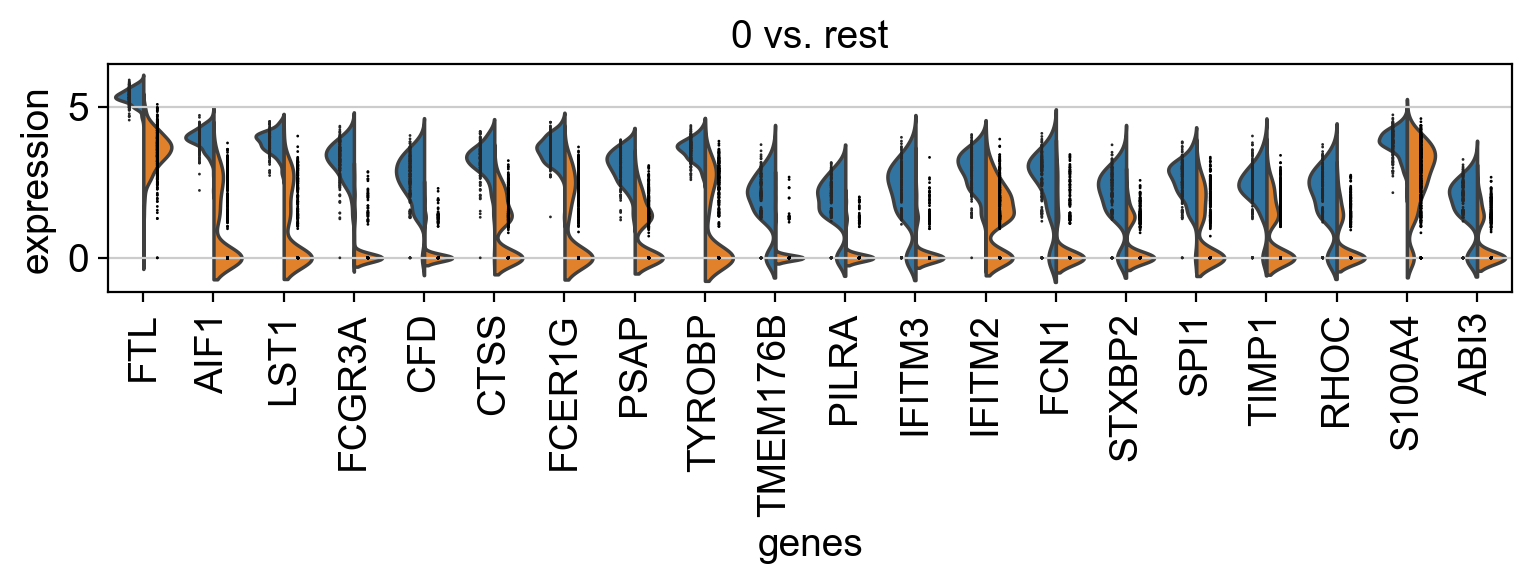